#  Cyber Attack / Intrusion Detection System
## Using Support Vector Machine (SVM) on UNSW-NB15 Dataset

---
**Course:** Data Computation — Spring '26  
**Dataset:** UNSW-NB15 Training Set  
**Task:** Binary & Multi-class Network Intrusion Detection  
**Model:** Support Vector Machine (SVM) with full pipeline  

---

## Dataset Overview

The **UNSW-NB15** dataset was created at the Australian Centre for Cyber Security (ACCS) and is a modern benchmark for network intrusion detection systems. It contains **82,332 records** with **45 features** capturing real network traffic mixed with synthetic attack scenarios.

### Feature Categories:
| Category | Features | Description |
|----------|----------|-------------|
| **Flow Features** | `dur`, `spkts`, `dpkts`, `sbytes`, `dbytes`, `rate` | Basic traffic statistics |
| **Basic Features** | `proto`, `service`, `state` | Protocol-level identifiers |
| **Content Features** | `sload`, `dload`, `sinpkt`, `dinpkt`, `sjit`, `djit` | Load and jitter metrics |
| **Time Features** | `sttl`, `dttl`, `tcprtt`, `synack`, `ackdat` | TTL and TCP handshake timing |
| **Additional Features** | `ct_*` features | Connection count-based features |
| **Target** | `label` (0=Normal, 1=Attack), `attack_cat` | Ground truth labels |

### Attack Categories in Dataset:
- **Normal** (37,000) — Benign traffic
- **Generic** (18,871) — Generic attacks
- **Exploits** (11,132) — Exploitation attacks
- **Fuzzers** (6,062) — Fuzzing attacks
- **DoS** (4,089) — Denial of Service
- **Reconnaissance** (3,496) — Scanning/probing
- **Analysis** (677), **Backdoor** (583), **Shellcode** (378), **Worms** (44)

---
##  Step 0: Import Libraries

In [1]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ─── Sklearn: Preprocessing ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

# ─── Sklearn: Dimensionality Reduction ────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# ─── Sklearn: SVM ─────────────────────────────────────────────────────────────
from sklearn.svm import SVC, LinearSVC

# ─── Sklearn: Evaluation ──────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    precision_score, recall_score, precision_recall_curve
)

# ─── Joblib for saving model ──────────────────────────────────────────────────
import joblib
import os
import time

# ─── Styling ──────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans'
})

RANDOM_STATE = 42
print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


---
##  Step 1: Load Data & Initial Inspection

In [2]:
# Load dataset
df = pd.read_csv('UNSW_NB15_training-set.csv')

print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📁 Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print("\n" + "="*60)
df.head()

📊 Dataset Shape: 82,332 rows × 45 columns
📁 Memory Usage: 44.38 MB



,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [3]:
# Feature types breakdown
print("=" * 55)
print("FEATURE TYPE BREAKDOWN")
print("=" * 55)
print(f"  Numerical (int/float) : {df.select_dtypes(include=np.number).shape[1]}")
print(f"  Categorical (object)  : {df.select_dtypes(include='object').shape[1]}")
print("\nCategorical columns:", df.select_dtypes(include='object').columns.tolist())
print("\nNumerical columns:")
for col in df.select_dtypes(include=np.number).columns:
    print(f"  {col:<30} range: [{df[col].min():.2f}, {df[col].max():.2f}]")

FEATURE TYPE BREAKDOWN
  Numerical (int/float) : 41
  Categorical (object)  : 4

Categorical columns: ['proto', 'service', 'state', 'attack_cat']

Numerical columns:
  id                             range: [1.00, 82332.00]
  dur                            range: [0.00, 60.00]
  spkts                          range: [1.00, 10646.00]
  dpkts                          range: [0.00, 11018.00]
  sbytes                         range: [24.00, 14355774.00]
  dbytes                         range: [0.00, 14657531.00]
  rate                           range: [0.00, 1000000.00]
  sttl                           range: [0.00, 255.00]
  dttl                           range: [0.00, 253.00]
  sload                          range: [0.00, 5268000256.00]
  dload                          range: [0.00, 20821108.00]
  sloss                          range: [0.00, 5319.00]
  dloss                          range: [0.00, 5507.00]
  sinpkt                         range: [0.00, 60009.99]
  dinpkt                    

---
##  Step 2: Train / Test Split  
> ⚠️ **CRITICAL:** We split the data **FIRST** before any preprocessing or analysis to prevent data leakage.

In [4]:
# Drop 'id' — it is a row identifier with no predictive value
df = df.drop(columns=['id'])

# Define features and target (binary classification: label 0/1)
# We also keep 'attack_cat' separate for multiclass reference
CATEGORICAL_COLS = ['proto', 'service', 'state']
TARGET = 'label'

# Drop 'attack_cat' — it is a string version of the label; using it
# would constitute direct target leakage.
X = df.drop(columns=[TARGET, 'attack_cat'])
y = df[TARGET]

# Stratified split — maintains class ratio in both splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("=" * 45)
print("TRAIN / TEST SPLIT (80% / 20%)")
print("=" * 45)
print(f"  Training set  : {X_train_raw.shape[0]:>6,} samples")
print(f"  Test set      : {X_test_raw.shape[0]:>6,} samples")
print(f"\nClass distribution in training set:")
for cls, cnt in y_train.value_counts().items():
    label = 'Normal' if cls == 0 else 'Attack'
    pct = cnt / len(y_train) * 100
    print(f"  {label} ({cls}): {cnt:,} ({pct:.1f}%)")
print(f"\nClass distribution in test set:")
for cls, cnt in y_test.value_counts().items():
    label = 'Normal' if cls == 0 else 'Attack'
    pct = cnt / len(y_test) * 100
    print(f"  {label} ({cls}): {cnt:,} ({pct:.1f}%)")

TRAIN / TEST SPLIT (80% / 20%)
  Training set  : 65,865 samples
  Test set      : 16,467 samples

Class distribution in training set:
  Attack (1): 36,265 (55.1%)
  Normal (0): 29,600 (44.9%)

Class distribution in test set:
  Attack (1): 9,067 (55.1%)
  Normal (0): 7,400 (44.9%)


---
##  Step 3: Exploratory Data Analysis (EDA)
> All EDA is performed on the **training set only** to avoid test data leakage.

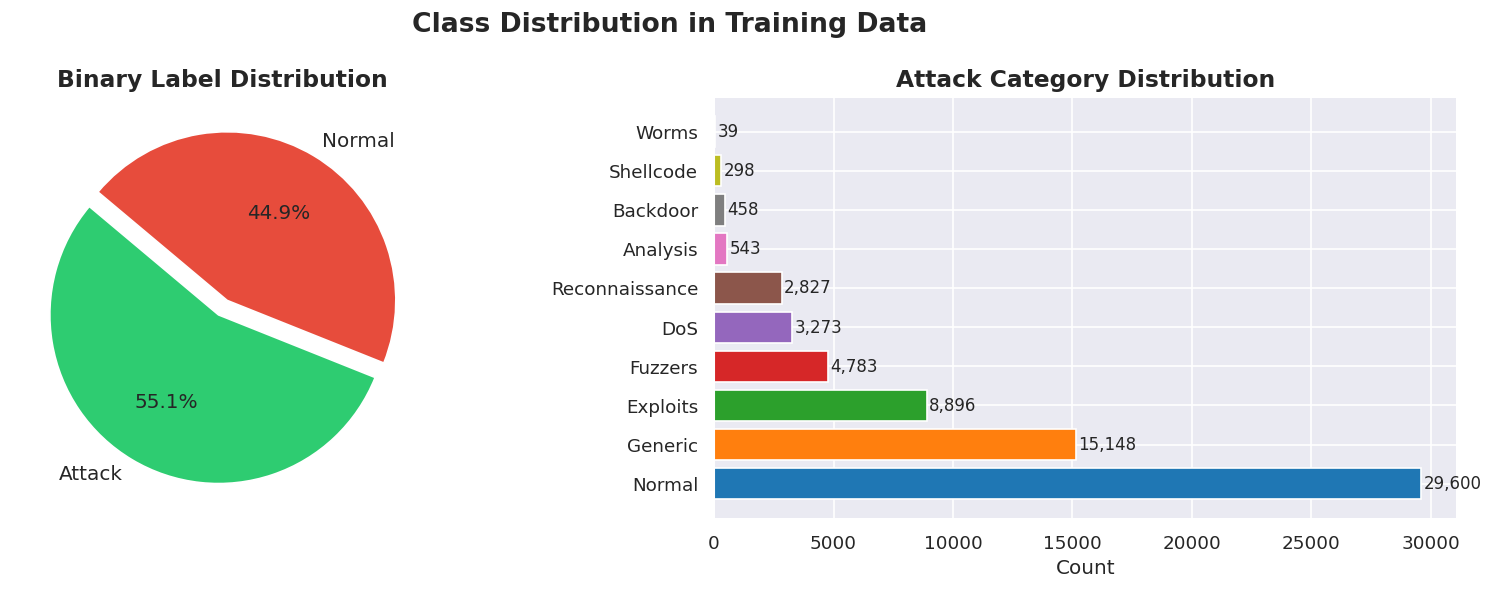

💡 Insight: Dataset is slightly imbalanced — attacks (55%) outnumber normal traffic (45%).


In [5]:
# Working copy for EDA — training data with labels
train_eda = X_train_raw.copy()
train_eda['label'] = y_train.values
train_eda['attack_cat'] = df.loc[X_train_raw.index, 'attack_cat'].values

# ── 3.1  Class Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution in Training Data', fontsize=16, fontweight='bold')

# Binary label
label_counts = train_eda['label'].map({0: 'Normal', 1: 'Attack'}).value_counts()
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    label_counts, labels=label_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=140, explode=[0.05, 0.05],
    textprops={'fontsize': 12}
)
axes[0].set_title('Binary Label Distribution', fontweight='bold')

# Attack categories
cat_counts = train_eda['attack_cat'].value_counts()
bar_colors = plt.cm.tab10(np.linspace(0, 1, len(cat_counts)))
bars = axes[1].barh(cat_counts.index, cat_counts.values, color=bar_colors)
axes[1].set_xlabel('Count')
axes[1].set_title('Attack Category Distribution', fontweight='bold')
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Dataset is slightly imbalanced — attacks (55%) outnumber normal traffic (45%).")

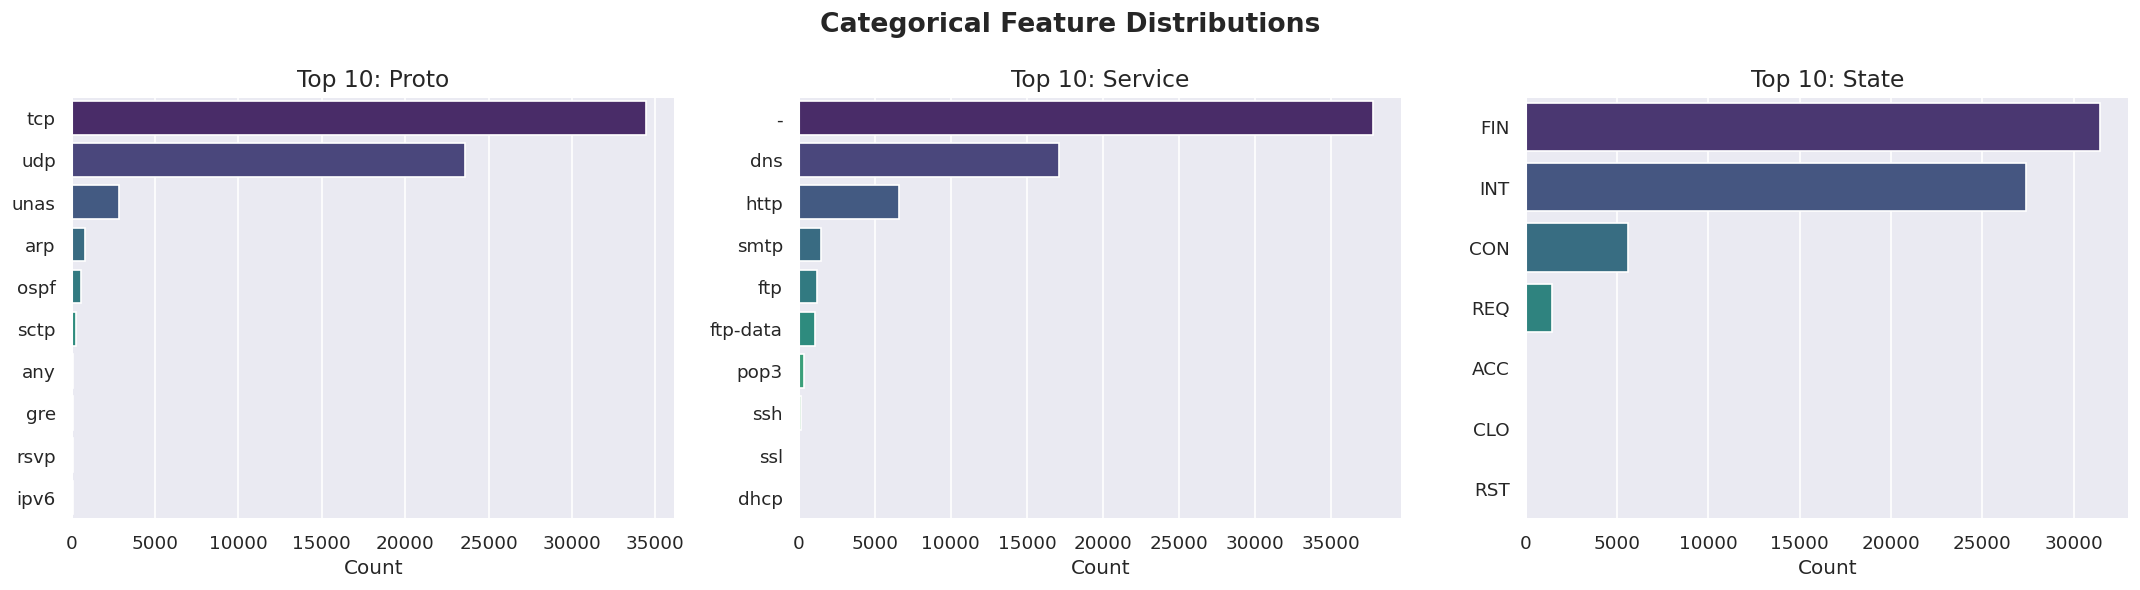

💡 Insight: UDP and TCP dominate traffic; '-' (unknown) service is highly prevalent.


In [6]:
# ── 3.2  Protocol, Service, and State distribution ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')

for ax, col in zip(axes, ['proto', 'service', 'state']):
    top = train_eda[col].value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, ax=ax, palette='viridis')
    ax.set_title(f'Top 10: {col.capitalize()}')
    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('fig2_categorical_distributions.png', bbox_inches='tight')
plt.show()
print("💡 Insight: UDP and TCP dominate traffic; '-' (unknown) service is highly prevalent.")

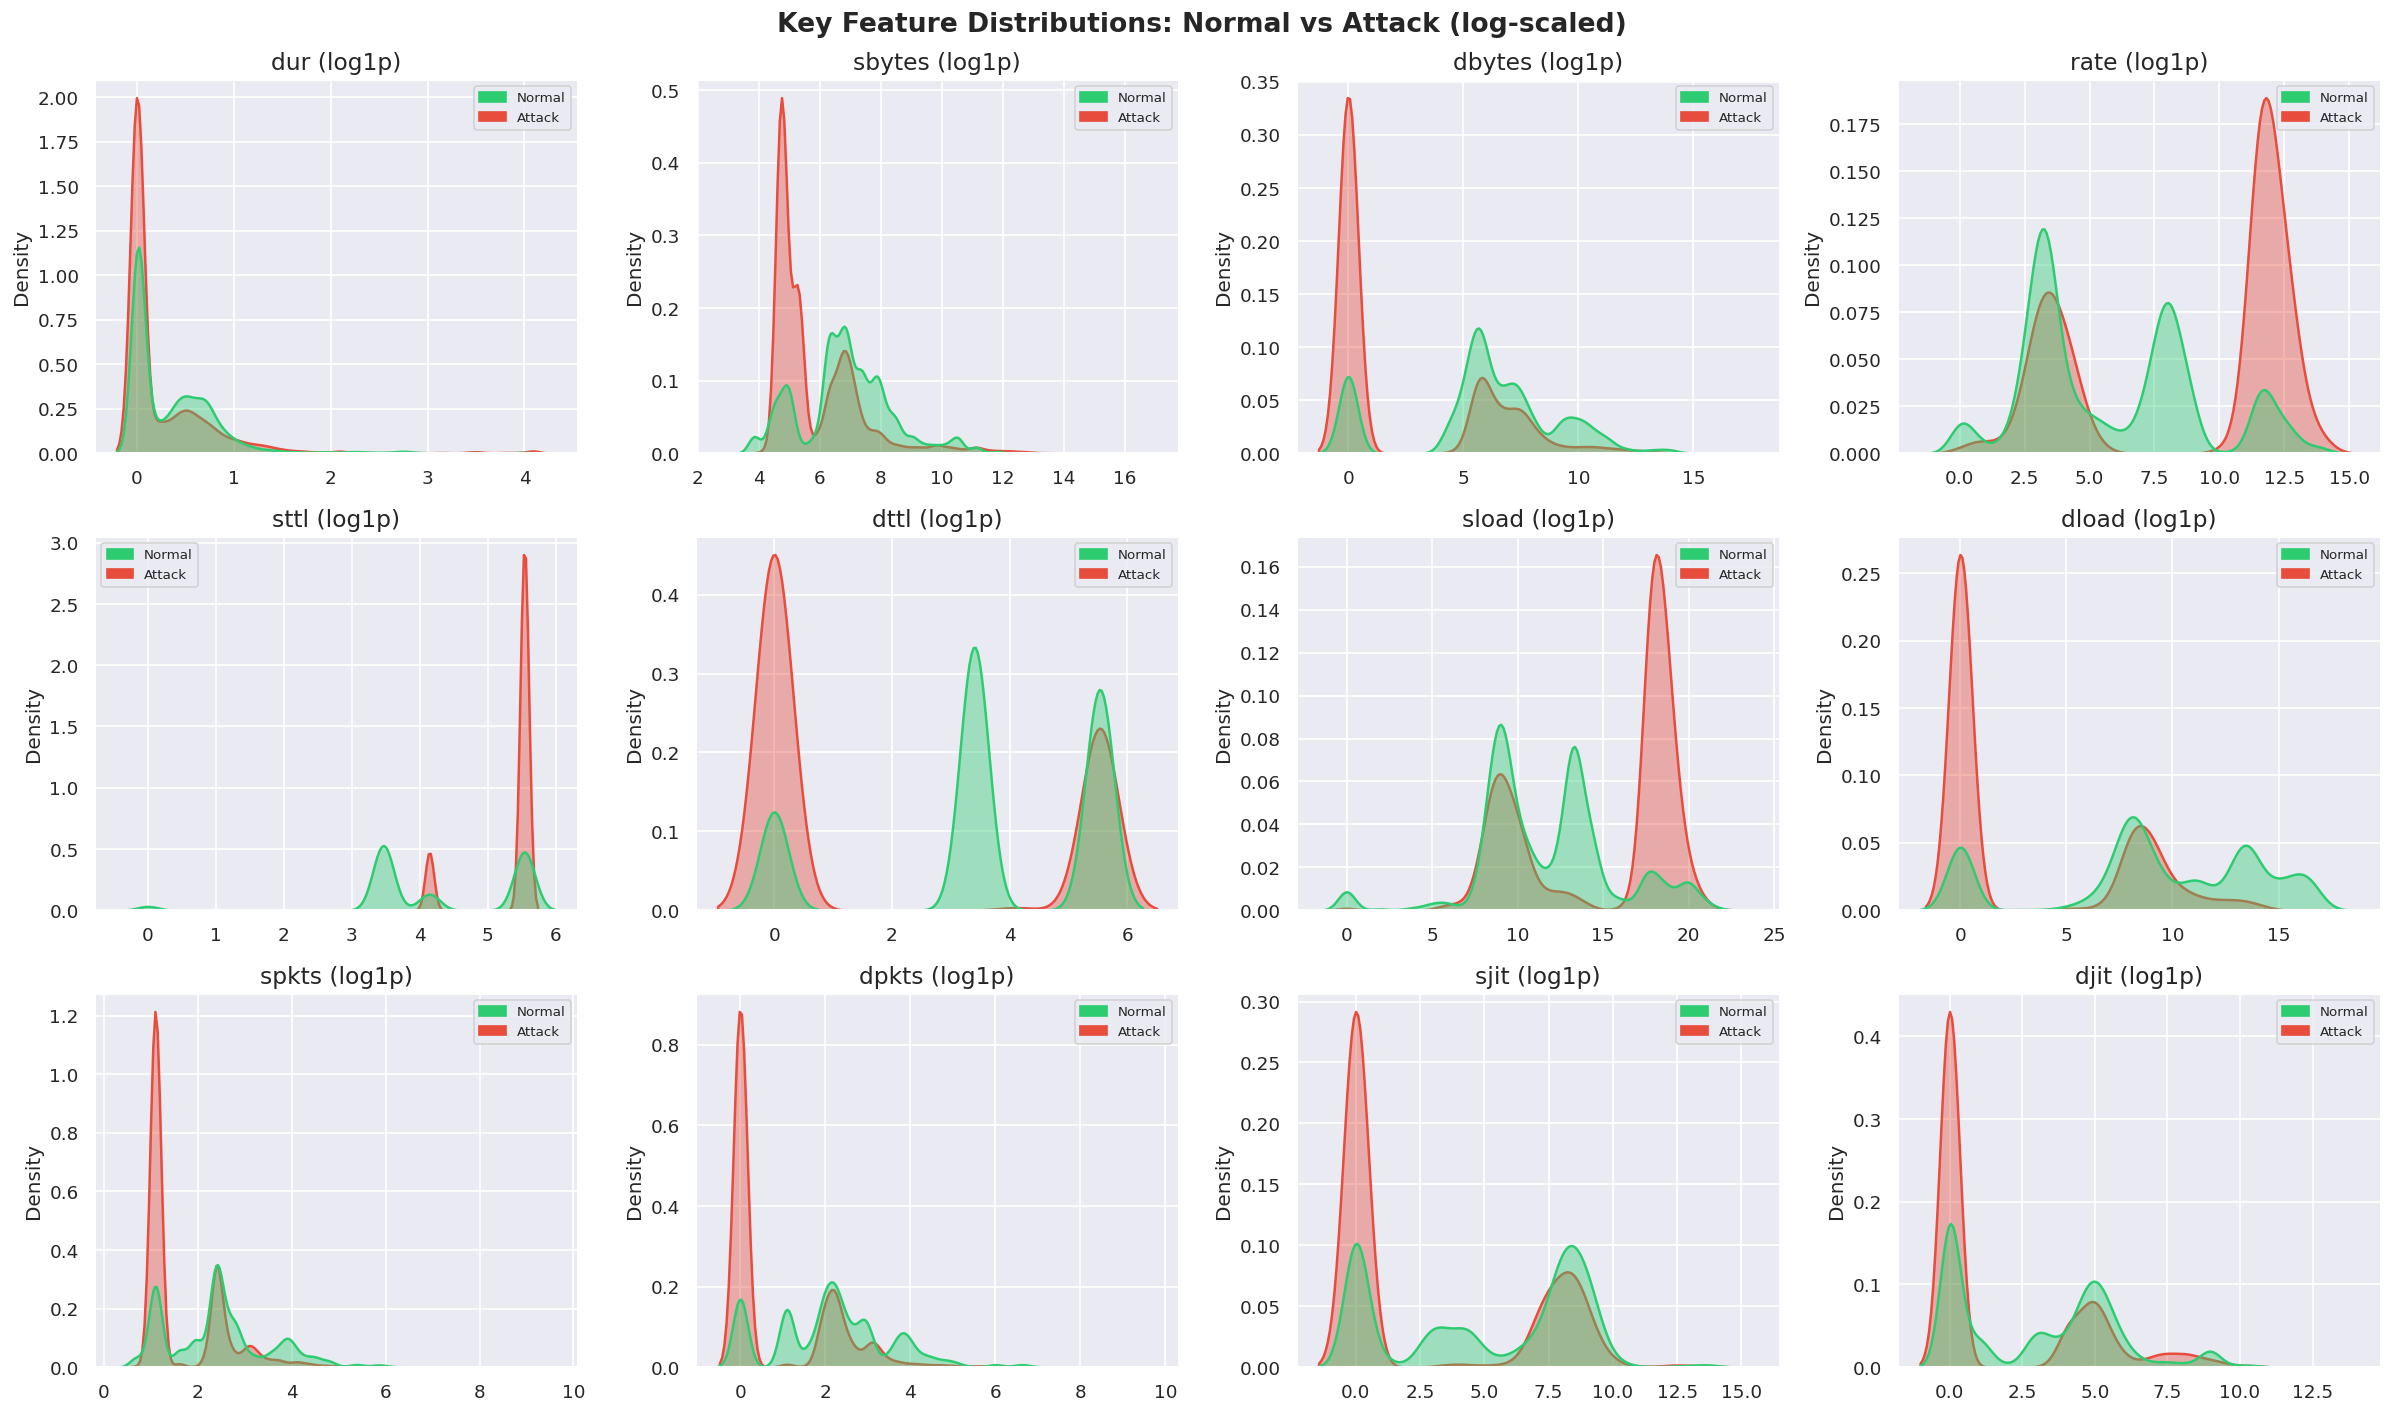

💡 Insight: sttl, dttl, rate, and sbytes show strong separation between Normal and Attack traffic.


In [7]:
# ── 3.3  Distribution of Key Numeric Features by Class ────────────────────────
key_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
                 'sload', 'dload', 'spkts', 'dpkts', 'sjit', 'djit']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Key Feature Distributions: Normal vs Attack (log-scaled)', fontsize=16, fontweight='bold')
axes = axes.flatten()

palette = {0: '#2ecc71', 1: '#e74c3c'}
for i, feat in enumerate(key_features):
    data = train_eda[[feat, 'label']].copy()
    # Log1p transform for visibility
    data[feat] = np.log1p(data[feat].clip(lower=0))
    sns.kdeplot(data=data, x=feat, hue='label', ax=axes[i],
                palette=palette, fill=True, alpha=0.4, linewidth=1.5)
    axes[i].set_title(f'{feat} (log1p)')
    axes[i].set_xlabel('')
    handles = [mpatches.Patch(color='#2ecc71', label='Normal'),
               mpatches.Patch(color='#e74c3c', label='Attack')]
    axes[i].legend(handles=handles, fontsize=8)

plt.tight_layout()
plt.savefig('fig3_feature_distributions.png', bbox_inches='tight')
plt.show()
print("💡 Insight: sttl, dttl, rate, and sbytes show strong separation between Normal and Attack traffic.")

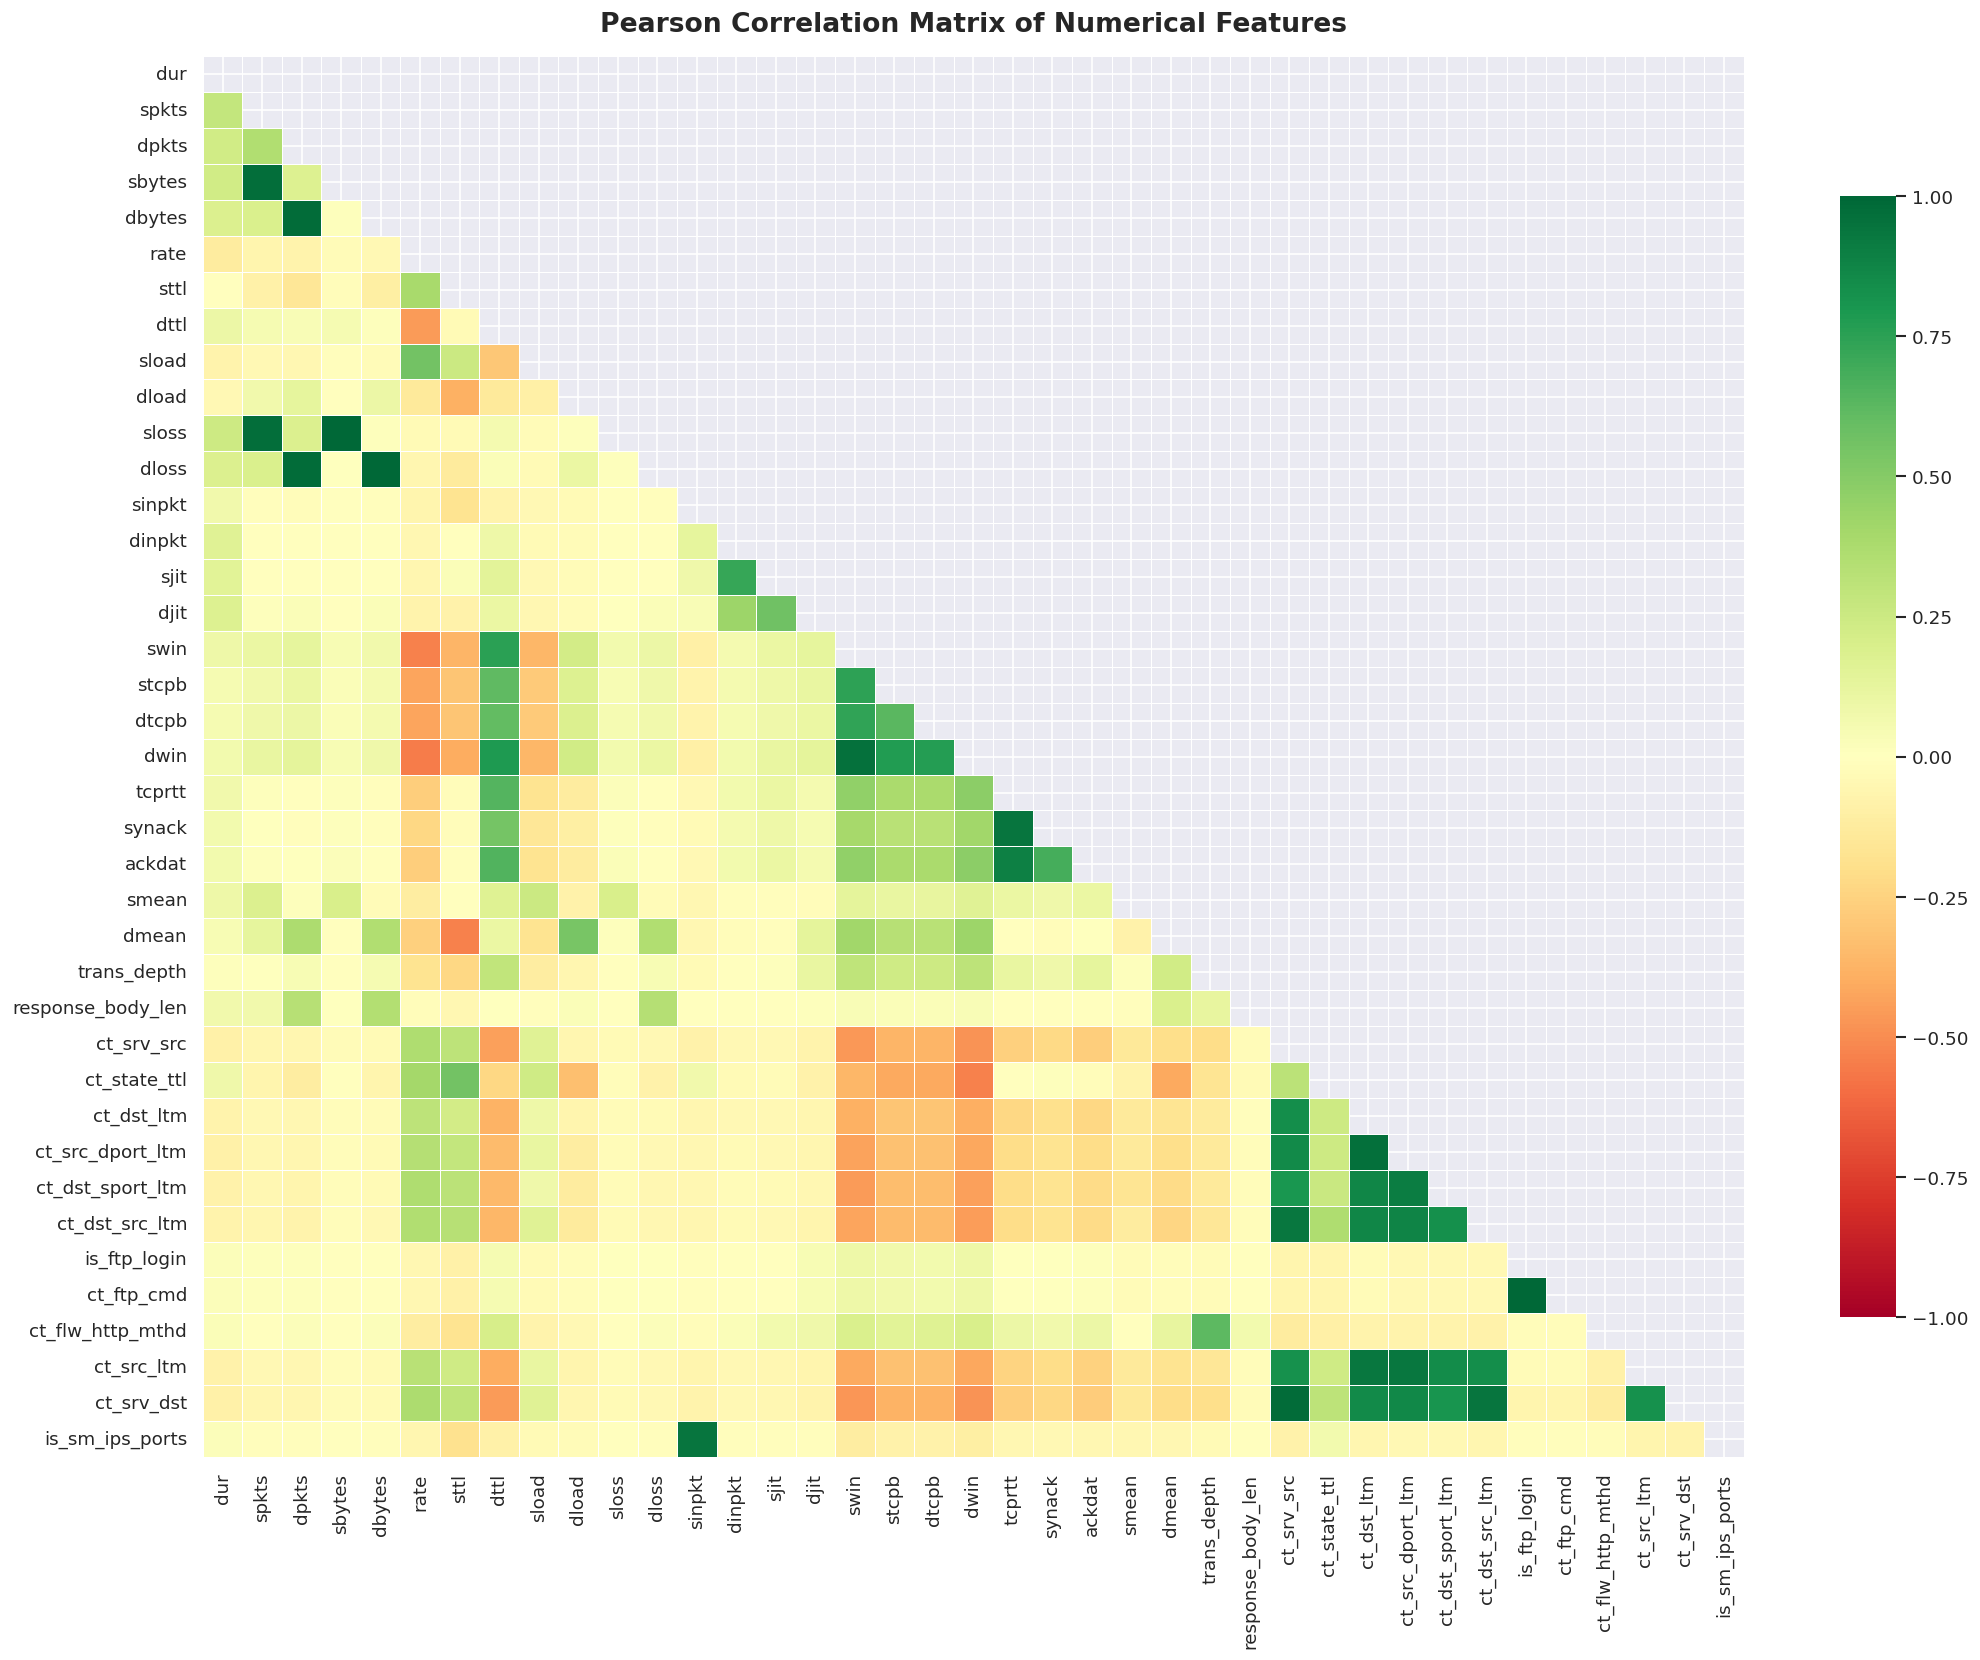

💡 Insight: Strong correlations exist between (sbytes/smean), (dbytes/dmean), and TCP window features.


In [8]:
# ── 3.4  Correlation Heatmap ──────────────────────────────────────────────────
num_cols = train_eda.select_dtypes(include=np.number).drop(columns=['label']).columns
corr_matrix = train_eda[num_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdYlGn', center=0,
    vmin=-1, vmax=1, annot=False, fmt='.1f',
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Strong correlations exist between (sbytes/smean), (dbytes/dmean), and TCP window features.")

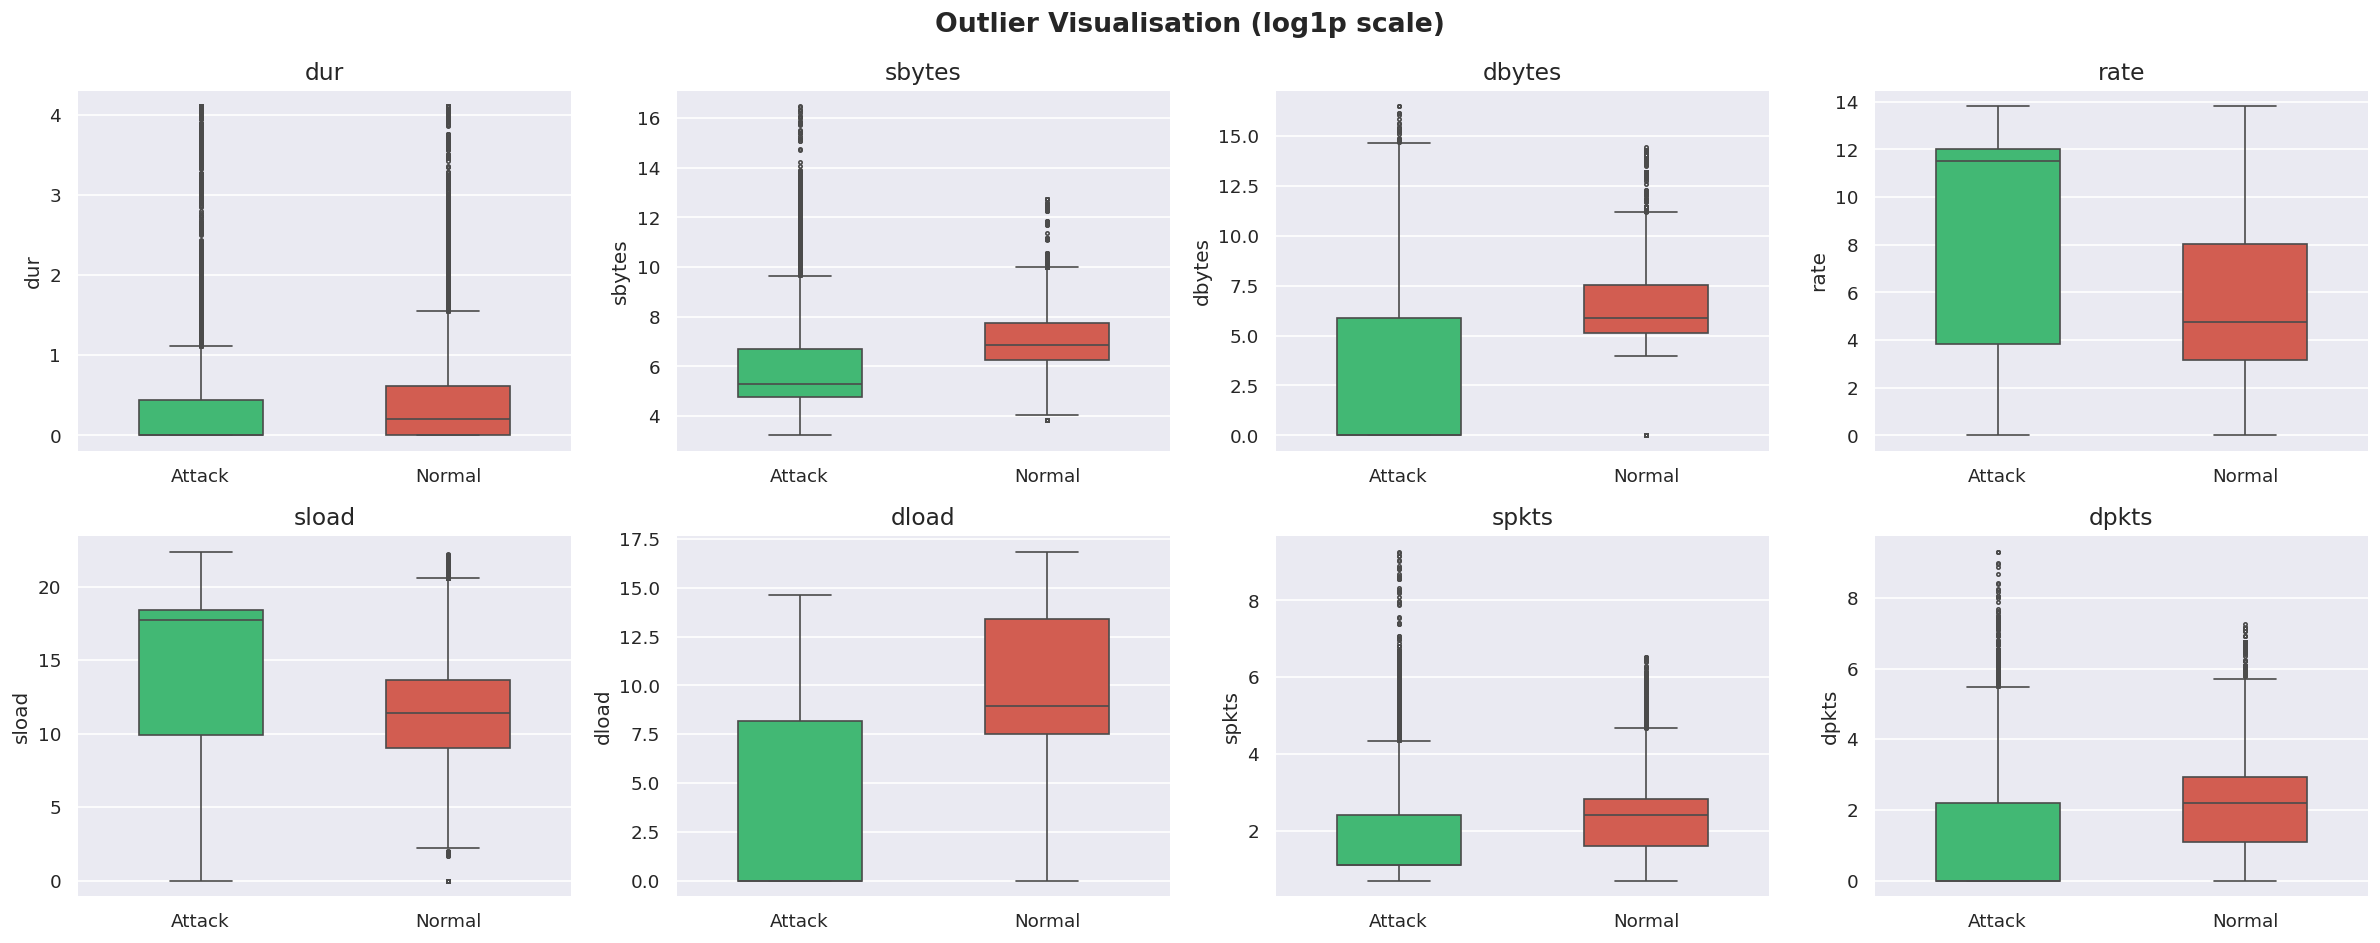

💡 Insight: Extreme outliers present in rate, sload, and sbytes — typical of attack traffic patterns.


In [9]:
# ── 3.5  Outlier Detection via IQR Boxplots ───────────────────────────────────
outlier_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'spkts', 'dpkts']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Outlier Visualisation (log1p scale)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(outlier_features):
    data_plot = train_eda[[feat, 'label']].copy()
    data_plot[feat] = np.log1p(data_plot[feat].clip(lower=0))
    data_plot['Class'] = data_plot['label'].map({0: 'Normal', 1: 'Attack'})
    sns.boxplot(data=data_plot, x='Class', y=feat, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'], width=0.5, fliersize=2)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('fig5_outlier_boxplots.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Extreme outliers present in rate, sload, and sbytes — typical of attack traffic patterns.")

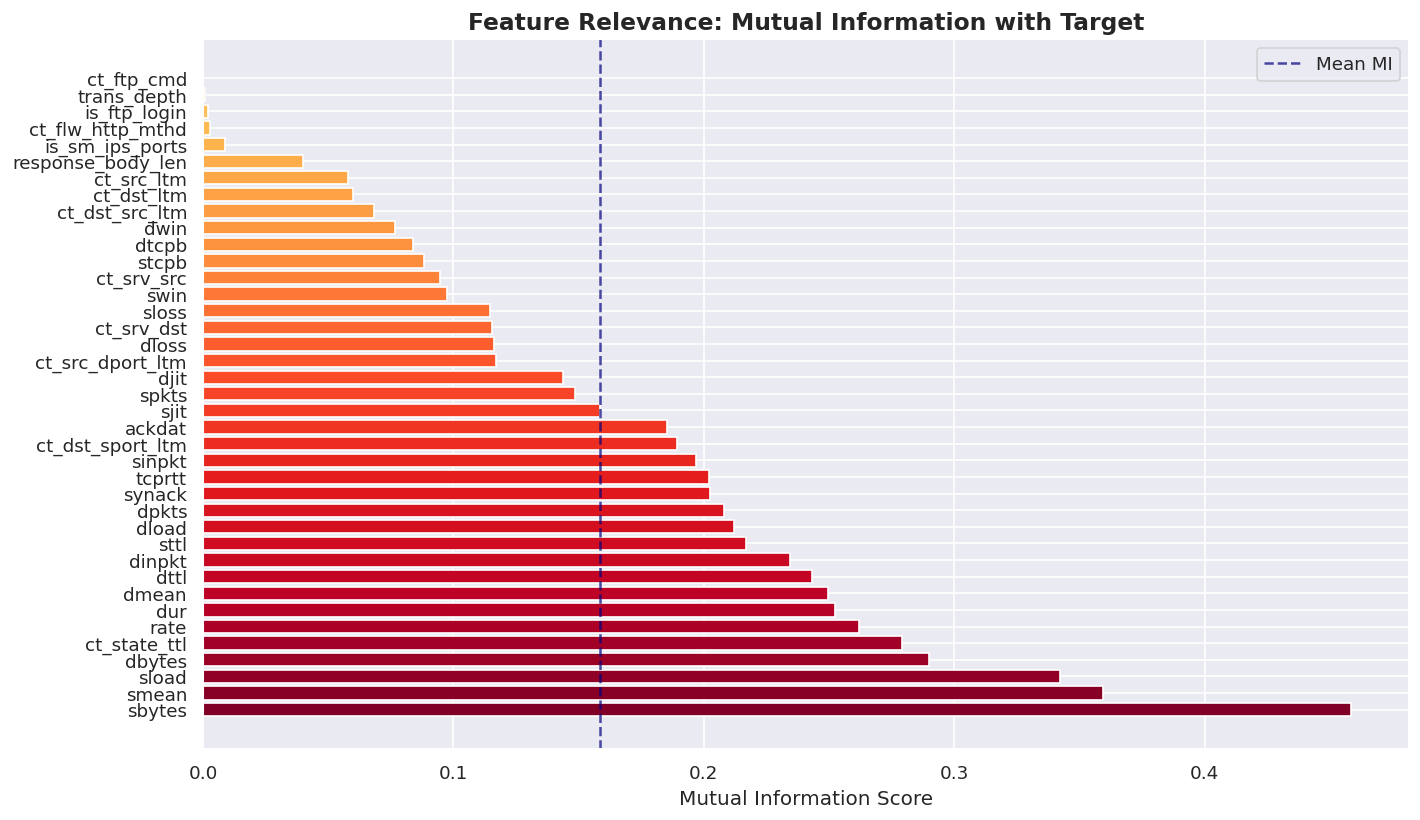

Top 10 most informative features:
     Feature  MI Score
      sbytes  0.458553
       smean  0.359358
       sload  0.342342
      dbytes  0.289877
ct_state_ttl  0.278997
        rate  0.261920
         dur  0.252208
       dmean  0.249638
        dttl  0.243359
      dinpkt  0.234427


In [10]:
# ── 3.6  Feature Importance via Mutual Information ───────────────────────────
# Quick numeric-only MI for EDA intuition
num_train = train_eda[num_cols].fillna(0)
mi_scores = mutual_info_classif(num_train, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': num_cols, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_mi = plt.cm.YlOrRd(np.linspace(0.3, 1, len(mi_df)))
bars = ax.barh(mi_df['Feature'], mi_df['MI Score'], color=colors_mi[::-1])
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Feature Relevance: Mutual Information with Target', fontsize=14, fontweight='bold')
ax.axvline(x=mi_df['MI Score'].mean(), color='navy', linestyle='--', alpha=0.7, label='Mean MI')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig6_mutual_information.png', bbox_inches='tight')
plt.show()
print("Top 10 most informative features:")
print(mi_df.head(10).to_string(index=False))

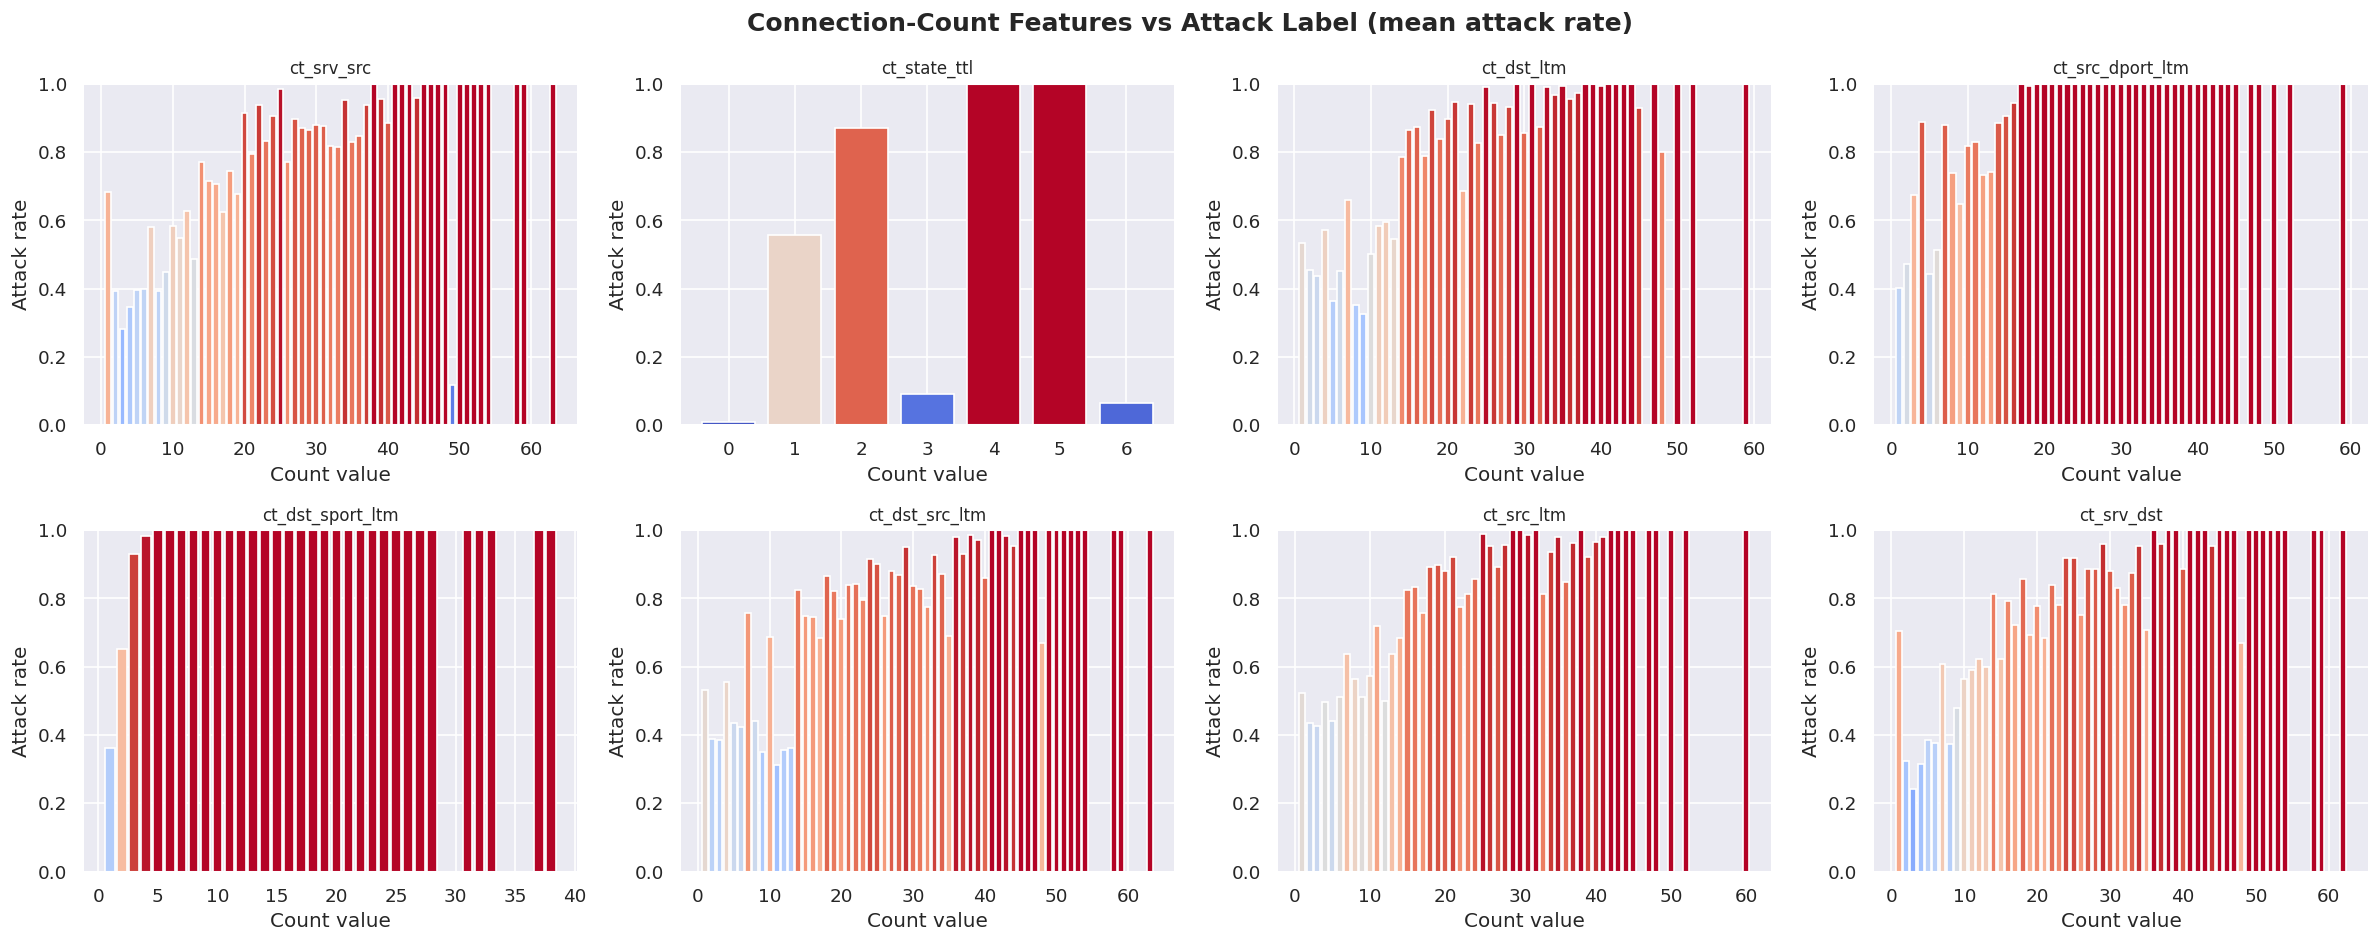

💡 Insight: ct_state_ttl and ct_srv_dst show strong attack-rate variation — useful discriminators.


In [11]:
# ── 3.7  Connection Features vs Attack Rate ───────────────────────────────────
ct_cols = ['ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm',
           'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Connection-Count Features vs Attack Label (mean attack rate)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(ct_cols):
    grouped = train_eda.groupby(col)['label'].mean().reset_index()
    grouped.columns = [col, 'attack_rate']
    axes[i].bar(grouped[col], grouped['attack_rate'],
                color=plt.cm.coolwarm(grouped['attack_rate'].values))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Count value')
    axes[i].set_ylabel('Attack rate')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig7_ct_features_attack_rate.png', bbox_inches='tight')
plt.show()
print("💡 Insight: ct_state_ttl and ct_srv_dst show strong attack-rate variation — useful discriminators.")

---
## Step 4: Data Cleaning

In [12]:
# ── 4.1  Missing Values ───────────────────────────────────────────────────────
print("=" * 45)
print("MISSING VALUE ANALYSIS")
print("=" * 45)
missing = X_train_raw.isnull().sum()
missing_pct = (missing / len(X_train_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
print(missing_df[missing_df['Missing'] > 0] if missing_df['Missing'].sum() > 0
      else "✅ No missing values found!")

MISSING VALUE ANALYSIS
✅ No missing values found!


In [13]:
# ── 4.2  Outlier Treatment via IQR Capping (Winsorisation) ───────────────────
# We use IQR-based capping (winsorisation) instead of dropping records.
# This preserves ALL records (per project guidelines) while reducing extreme values.

NUMERIC_FEATURES = X_train_raw.select_dtypes(include=np.number).columns.tolist()
OUTLIER_FEATURES = ['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
                     'spkts', 'dpkts', 'sloss', 'dloss', 'sinpkt', 'dinpkt',
                     'sjit', 'djit', 'response_body_len']

# Calculate IQR bounds from TRAINING data only
outlier_bounds = {}
for col in OUTLIER_FEATURES:
    Q1 = X_train_raw[col].quantile(0.01)
    Q3 = X_train_raw[col].quantile(0.99)
    outlier_bounds[col] = (Q1, Q3)

def apply_winsorisation(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=lo, upper=hi)
    return df

X_train_clean = apply_winsorisation(X_train_raw, outlier_bounds)
X_test_clean  = apply_winsorisation(X_test_raw,  outlier_bounds)

print("=" * 50)
print("OUTLIER CAPPING SUMMARY (1st–99th percentile)")
print("=" * 50)
for col, (lo, hi) in list(outlier_bounds.items())[:5]:
    original_max = X_train_raw[col].max()
    capped_max = X_train_clean[col].max()
    print(f"  {col:<25} cap: [{lo:.2f}, {hi:.2f}] | orig_max={original_max:.2f} → {capped_max:.2f}")

print(f"\n✅ Records in training set: {len(X_train_clean):,} (NO records dropped)")

OUTLIER CAPPING SUMMARY (1st–99th percentile)
  dur                       cap: [0.00, 21.11] | orig_max=60.00 → 21.11
  sbytes                    cap: [46.00, 69090.12] | orig_max=14355774.00 → 69090.12
  dbytes                    cap: [0.00, 192828.00] | orig_max=14657531.00 → 192828.00
  rate                      cap: [0.00, 1000000.00] | orig_max=1000000.00 → 1000000.00
  sload                     cap: [0.00, 800000000.00] | orig_max=5268000256.00 → 800000000.00

✅ Records in training set: 65,865 (NO records dropped)


In [14]:
# ── 4.3  Duplicate Check ──────────────────────────────────────────────────────
n_dup_train = X_train_raw.duplicated().sum()
n_dup_test  = X_test_raw.duplicated().sum()
print(f"Duplicate rows — Train: {n_dup_train} | Test: {n_dup_test}")

# If duplicates exist in training set — we keep them to preserve the
# dataset size as per project guidelines. Duplicates in network traffic
# can represent repeated packets which are legitimate features.
print("\n📌 Decision: Duplicates retained (each row represents a unique flow snapshot).")

Duplicate rows — Train: 21634 | Test: 3423

📌 Decision: Duplicates retained (each row represents a unique flow snapshot).


---
##  Step 5: Preprocessing — Encoding & Scaling

In [15]:
# ── 5.1  Label Encoding for Categorical Features ──────────────────────────────
# Fit encoders ONLY on training data
label_encoders = {}
X_train_enc = X_train_clean.copy()
X_test_enc  = X_test_clean.copy()

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
    # Handle unseen categories in test
    X_test_enc[col] = X_test_enc[col].astype(str).apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le

print("Categorical encoding summary:")
for col, le in label_encoders.items():
    print(f"  {col:<10}: {len(le.classes_)} unique classes → integer encoded")

print(f"\n✅ Feature matrix shape after encoding: {X_train_enc.shape}")

Categorical encoding summary:
  proto     : 131 unique classes → integer encoded
  service   : 13 unique classes → integer encoded
  state     : 7 unique classes → integer encoded

✅ Feature matrix shape after encoding: (65865, 42)


In [16]:
# ── 5.2  Robust Scaling ───────────────────────────────────────────────────────
# RobustScaler uses median/IQR — less sensitive to remaining outliers than StandardScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

feature_names = X_train_enc.columns.tolist()

print(f"✅ Robust scaling applied.")
print(f"   Training set: {X_train_scaled.shape}")
print(f"   Test set    : {X_test_scaled.shape}")
print(f"\n   Sample means after scaling (should be ~0):")
means = X_train_scaled.mean(axis=0)
print(f"   min={means.min():.4f}, max={means.max():.4f}, std={means.std():.4f}")

✅ Robust scaling applied.
   Training set: (65865, 42)
   Test set    : (16467, 42)

   Sample means after scaling (should be ~0):
   min=-0.4971, max=97.0742, std=15.7584


---
##  Step 6: Dimensionality Reduction
We apply **two complementary techniques**:
1. **SelectKBest (ANOVA F-test)** — filter-based feature selection to remove statistically irrelevant features.
2. **PCA** — further compress the selected features to capture maximum variance in fewer dimensions.

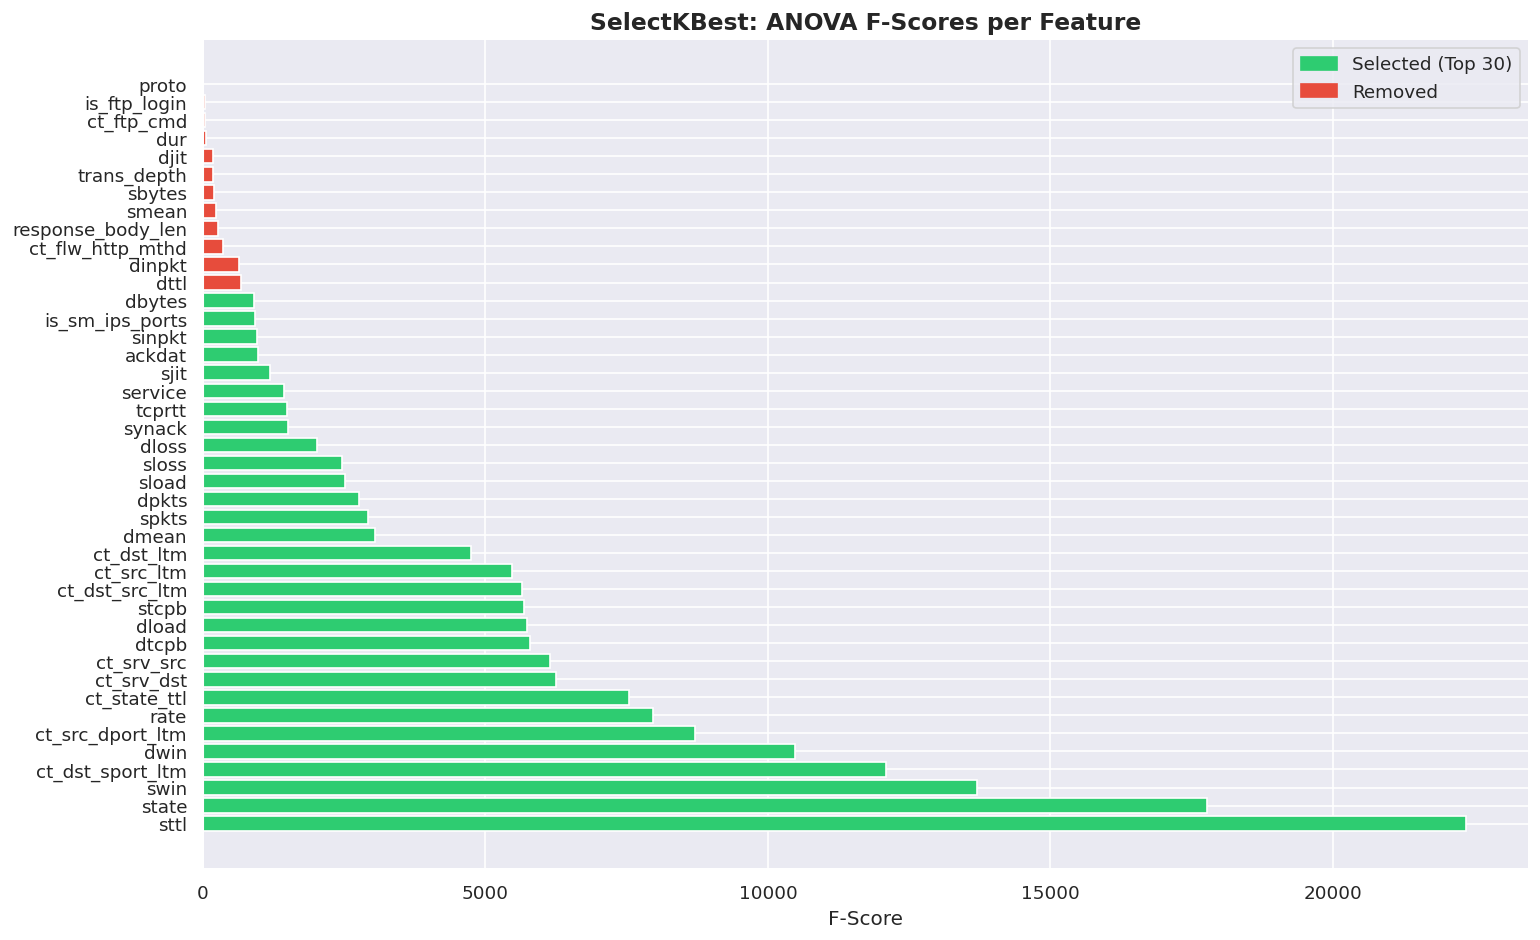


✅ Dimensionality reduced: 42 → 30 features

Removed features: ['dur', 'proto', 'sbytes', 'dttl', 'dinpkt', 'djit', 'smean', 'trans_depth', 'response_body_len', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd']


In [17]:
# ── 6.1  SelectKBest (ANOVA F-test) ──────────────────────────────────────────
K_BEST = 30  # Keep top 30 features out of 42

selector = SelectKBest(score_func=f_classif, k=K_BEST)
X_train_kbest = selector.fit_transform(X_train_scaled, y_train)
X_test_kbest  = selector.transform(X_test_scaled)

# Get selected feature names
selected_mask   = selector.get_support()
selected_features = [feature_names[i] for i, m in enumerate(selected_mask) if m]
removed_features  = [feature_names[i] for i, m in enumerate(selected_mask) if not m]

# Plot F-scores
scores = selector.scores_
fi_df = pd.DataFrame({'Feature': feature_names, 'F-Score': scores,
                        'Selected': selected_mask})
fi_df = fi_df.sort_values('F-Score', ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
bar_colors = ['#2ecc71' if s else '#e74c3c' for s in fi_df['Selected']]
ax.barh(fi_df['Feature'], fi_df['F-Score'], color=bar_colors)
selected_patch = mpatches.Patch(color='#2ecc71', label='Selected (Top 30)')
removed_patch  = mpatches.Patch(color='#e74c3c', label='Removed')
ax.legend(handles=[selected_patch, removed_patch], fontsize=11)
ax.set_title('SelectKBest: ANOVA F-Scores per Feature', fontsize=14, fontweight='bold')
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.savefig('fig8_feature_selection.png', bbox_inches='tight')
plt.show()

print(f"\n✅ Dimensionality reduced: 42 → 30 features")
print(f"\nRemoved features: {removed_features}")

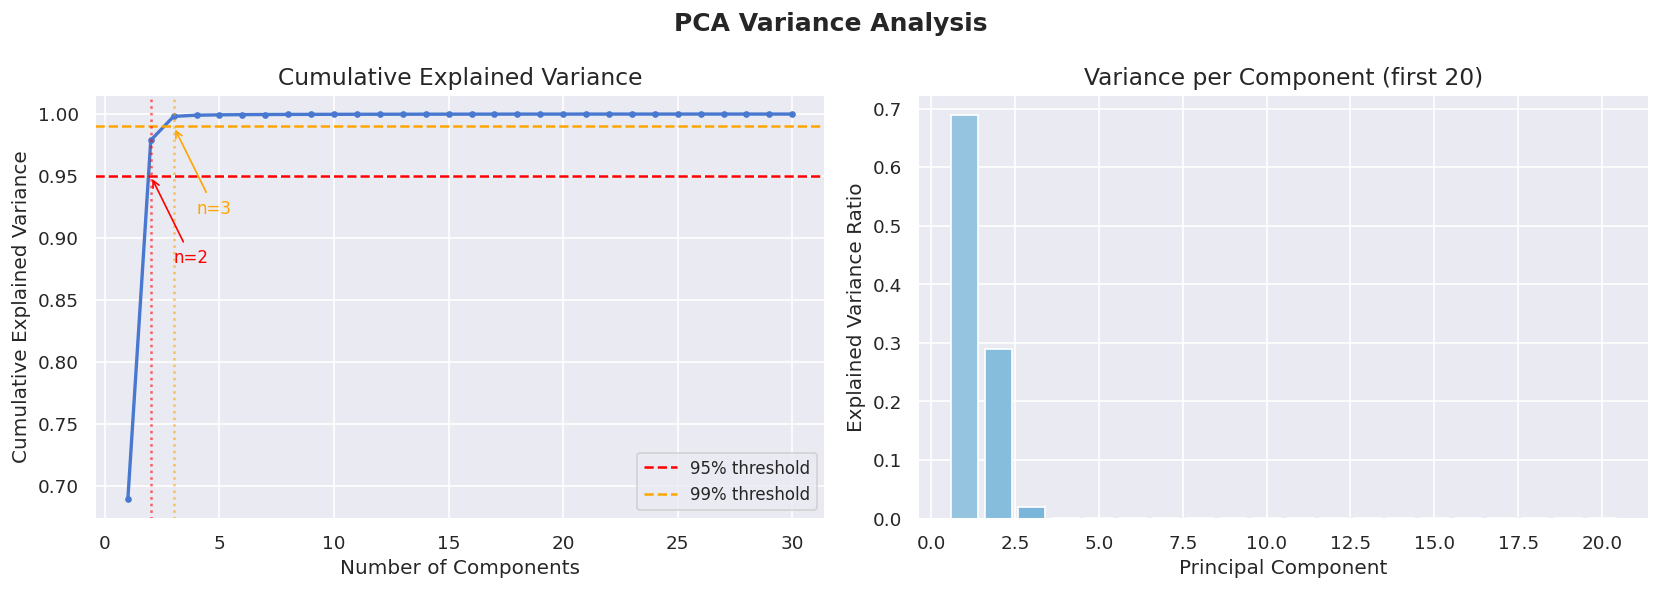

📊 Components needed to retain 95% variance: 2
📊 Components needed to retain 99% variance: 3

✅ Chosen: n_components = 2 (95% variance retention)


In [18]:
# ── 6.2  PCA — Variance Retention Analysis ───────────────────────────────────
# First, compute full PCA to find optimal n_components
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_kbest)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(explained_var >= 0.95) + 1
n_99 = np.argmax(explained_var >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Variance Analysis', fontsize=15, fontweight='bold')

# Cumulative variance
axes[0].plot(range(1, len(explained_var)+1), explained_var, 'b-o', markersize=3, linewidth=2)
axes[0].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[0].axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
axes[0].axvline(x=n_95, color='red', linestyle=':', alpha=0.6)
axes[0].axvline(x=n_99, color='orange', linestyle=':', alpha=0.6)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Cumulative Explained Variance')
axes[0].legend(fontsize=10)
axes[0].annotate(f'n={n_95}', xy=(n_95, 0.95), xytext=(n_95+1, 0.88),
                  fontsize=10, color='red',
                  arrowprops=dict(arrowstyle='->', color='red'))
axes[0].annotate(f'n={n_99}', xy=(n_99, 0.99), xytext=(n_99+1, 0.92),
                  fontsize=10, color='orange',
                  arrowprops=dict(arrowstyle='->', color='orange'))

# Individual variance
axes[1].bar(range(1, 21), pca_full.explained_variance_ratio_[:20],
            color=plt.cm.Blues(np.linspace(0.4, 1, 20)))
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Variance per Component (first 20)')

plt.tight_layout()
plt.savefig('fig9_pca_variance.png', bbox_inches='tight')
plt.show()

print(f"📊 Components needed to retain 95% variance: {n_95}")
print(f"📊 Components needed to retain 99% variance: {n_99}")
print(f"\n✅ Chosen: n_components = {n_95} (95% variance retention)")

DIMENSIONALITY REDUCTION SUMMARY
  Original features      : 42
  After SelectKBest (k=30): 30
  After PCA (95% var)    : 2
  Reduction factor       : 21.0x
  Variance retained      : 97.88%


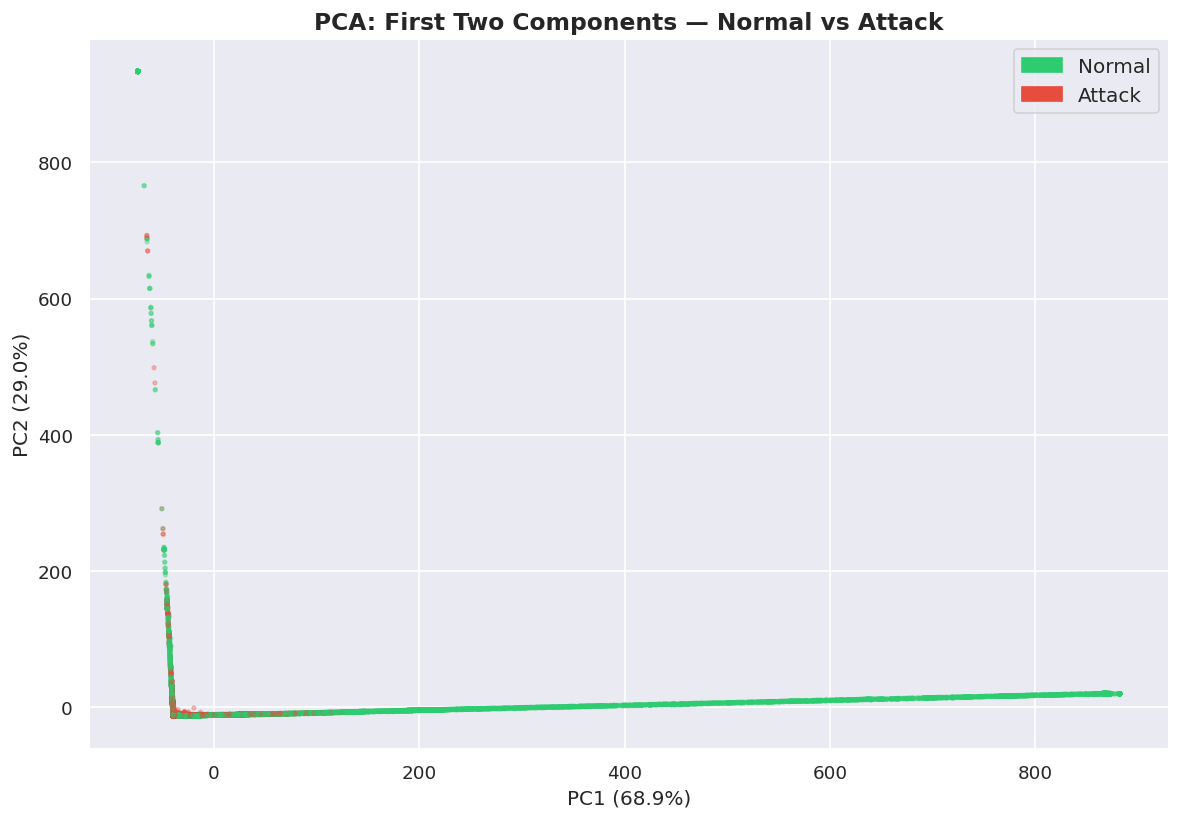

💡 Insight: Good class separation visible in the first two PCA components.


In [19]:
# ── 6.3  Apply PCA ────────────────────────────────────────────────────────────
N_PCA = n_95

pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_kbest)
X_test_pca  = pca.transform(X_test_kbest)

print(f"=" * 50)
print(f"DIMENSIONALITY REDUCTION SUMMARY")
print(f"=" * 50)
print(f"  Original features      : 42")
print(f"  After SelectKBest (k=30): 30")
print(f"  After PCA (95% var)    : {N_PCA}")
print(f"  Reduction factor       : {42/N_PCA:.1f}x")
print(f"  Variance retained      : {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Visualise first 2 PCA components
fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(y_train == 0, '#2ecc71', '#e74c3c')
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=colors, alpha=0.3, s=5, rasterized=True)
normal_patch = mpatches.Patch(color='#2ecc71', label='Normal')
attack_patch = mpatches.Patch(color='#e74c3c', label='Attack')
ax.legend(handles=[normal_patch, attack_patch], fontsize=12)
ax.set_title('PCA: First Two Components — Normal vs Attack', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('fig10_pca_scatter.png', bbox_inches='tight')
plt.show()
print("💡 Insight: Good class separation visible in the first two PCA components.")

---
## Step 7: SVM Model Development & Hyperparameter Tuning

In [20]:
# ── 7.1  Baseline SVM (LinearSVC — fast) ─────────────────────────────────────
print("Training Baseline LinearSVC...")
t0 = time.time()

baseline_svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE
)
baseline_svm.fit(X_train_pca, y_train)
y_pred_baseline = baseline_svm.predict(X_test_pca)

elapsed = time.time() - t0
print(f"✅ Baseline trained in {elapsed:.1f}s")
print(f"\nBaseline Accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Baseline F1-Score : {f1_score(y_test, y_pred_baseline):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_baseline, target_names=['Normal', 'Attack']))

Training Baseline LinearSVC...
✅ Baseline trained in 0.2s

Baseline Accuracy : 0.7071
Baseline F1-Score : 0.7836

Classification Report:

              precision    recall  f1-score   support

      Normal       0.90      0.39      0.55      7400
      Attack       0.66      0.96      0.78      9067

    accuracy                           0.71     16467
   macro avg       0.78      0.68      0.67     16467
weighted avg       0.77      0.71      0.68     16467



In [21]:
# ── 7.2  Hyperparameter Tuning via GridSearchCV ───────────────────────────────
# We use LinearSVC for efficiency on the full dataset.
# Grid search over C (regularisation) and loss function.

print("Running GridSearchCV hyperparameter tuning...")
print("(This may take a few minutes)\n")

param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'loss': ['squared_hinge'],
    'class_weight': ['balanced', None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
grid_search.fit(X_train_pca, y_train)
elapsed = time.time() - t0

print(f"\n✅ GridSearch completed in {elapsed:.1f}s")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Running GridSearchCV hyperparameter tuning...
(This may take a few minutes)

Fitting 5 folds for each of 10 candidates, totalling 50 fits



✅ GridSearch completed in 7.4s
Best parameters : {'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
Best CV F1-Score: 0.7803


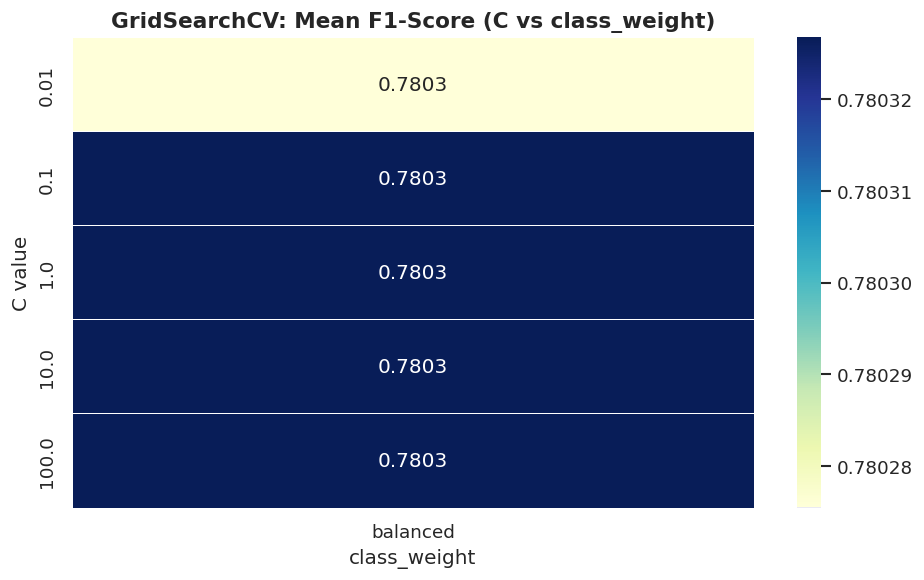

In [22]:
# ── 7.3  GridSearch Results Heatmap ──────────────────────────────────────────
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df.pivot_table(
    index='param_C',
    columns='param_class_weight',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('GridSearchCV: Mean F1-Score (C vs class_weight)', fontsize=13, fontweight='bold')
ax.set_xlabel('class_weight')
ax.set_ylabel('C value')
plt.tight_layout()
plt.savefig('fig11_gridsearch_results.png', bbox_inches='tight')
plt.show()

In [23]:
# ── 7.4  Final Tuned Model ────────────────────────────────────────────────────
best_svm = grid_search.best_estimator_
y_pred_final = best_svm.predict(X_test_pca)

print("=" * 55)
print("FINAL TUNED MODEL PERFORMANCE ON TEST SET")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_final):.4f}")
print()
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Attack']))

FINAL TUNED MODEL PERFORMANCE ON TEST SET
  Accuracy  : 0.7071
  Precision : 0.6605
  Recall    : 0.9631
  F1-Score  : 0.7836

              precision    recall  f1-score   support

      Normal       0.90      0.39      0.55      7400
      Attack       0.66      0.96      0.78      9067

    accuracy                           0.71     16467
   macro avg       0.78      0.68      0.67     16467
weighted avg       0.77      0.71      0.68     16467



---
##  Step 8: Model Evaluation & Visualisations

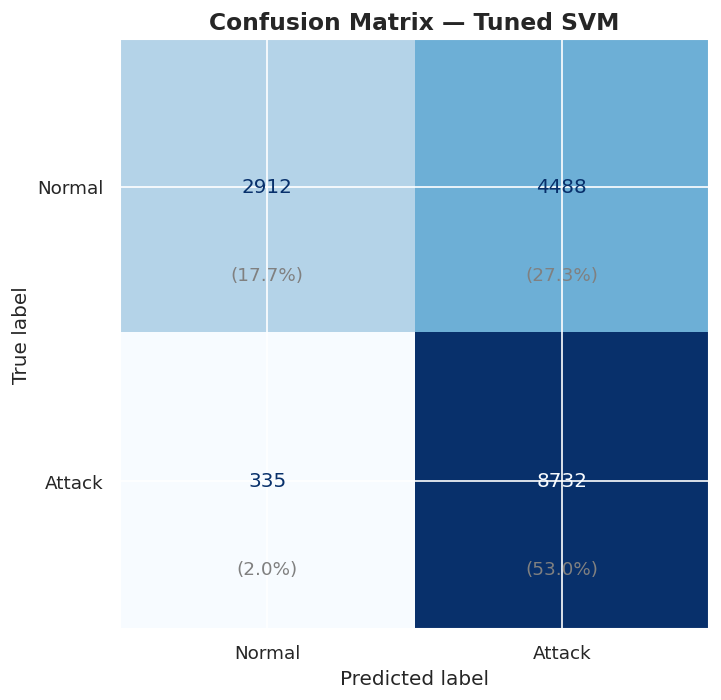


True  Negatives (correctly classified Normal) : 2,912
False Positives (Normal misclassified as Attack): 4,488
False Negatives (Attack misclassified as Normal): 335
True  Positives (correctly classified Attack)  : 8,732


In [24]:
# ── 8.1  Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Tuned SVM', fontsize=14, fontweight='bold')

# Annotate with percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.3, f'({cm[i,j]/total*100:.1f}%)',
                ha='center', va='center', fontsize=11, color='gray')

plt.tight_layout()
plt.savefig('fig12_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (correctly classified Normal) : {tn:,}")
print(f"False Positives (Normal misclassified as Attack): {fp:,}")
print(f"False Negatives (Attack misclassified as Normal): {fn:,}")
print(f"True  Positives (correctly classified Attack)  : {tp:,}")

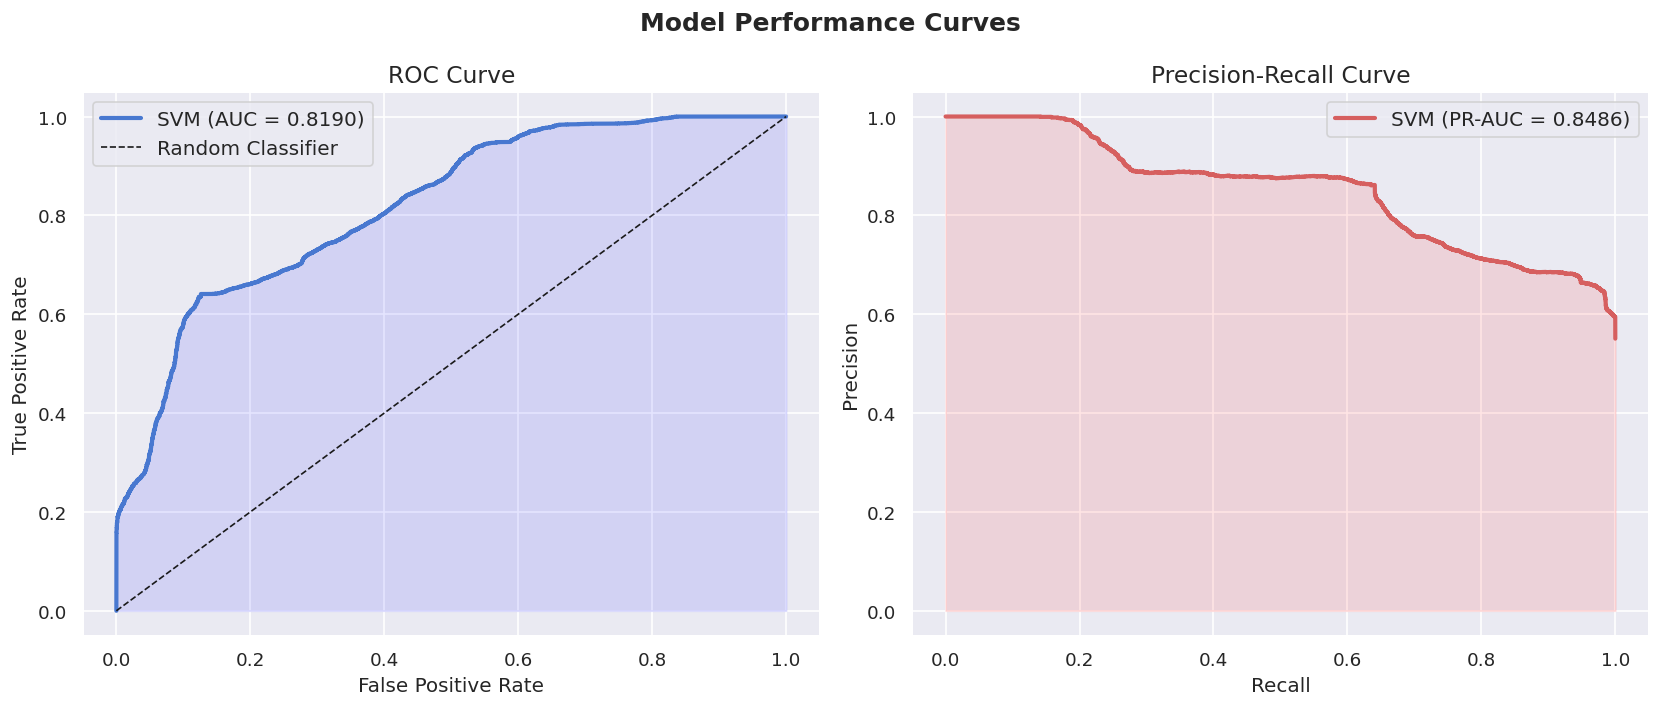

ROC-AUC  : 0.8190
PR-AUC   : 0.8486


In [25]:
# ── 8.2  ROC-AUC Curve ───────────────────────────────────────────────────────
# LinearSVC doesn't have predict_proba; use decision_function
y_scores = best_svm.decision_function(X_test_pca)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

# Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_scores)

pr_auc = np.trapezoid(precision_vals[::-1], recall_vals[::-1])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Curves', fontsize=15, fontweight='bold')

# ROC
axes[0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'SVM (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=12)

# PR Curve
axes[1].plot(recall_vals, precision_vals, 'r-', linewidth=2.5,
              label=f'SVM (PR-AUC = {pr_auc:.4f})')
axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='red')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('fig13_roc_pr_curves.png', bbox_inches='tight')
plt.show()

print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

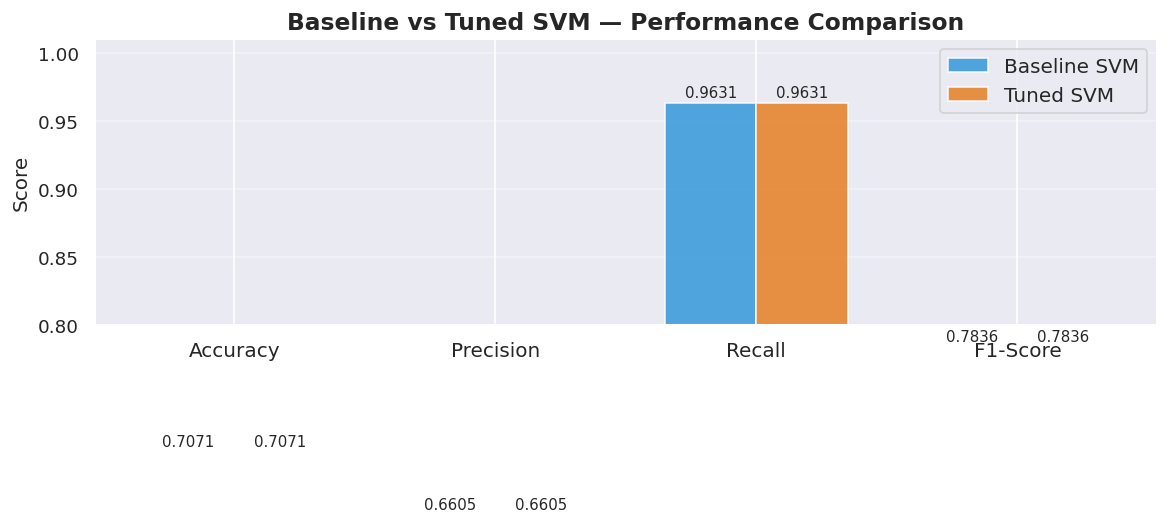

In [26]:
# ── 8.3  Model Comparison: Baseline vs Tuned ─────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

baseline_scores = [
    accuracy_score(y_test, y_pred_baseline),
    precision_score(y_test, y_pred_baseline),
    recall_score(y_test, y_pred_baseline),
    f1_score(y_test, y_pred_baseline)
]

tuned_scores = [
    accuracy_score(y_test, y_pred_final),
    precision_score(y_test, y_pred_final),
    recall_score(y_test, y_pred_final),
    f1_score(y_test, y_pred_final)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline SVM', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, tuned_scores,   width, label='Tuned SVM',    color='#e67e22', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned SVM — Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.80, 1.01)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig14_model_comparison.png', bbox_inches='tight')
plt.show()

---
## Step 9: Full Pipeline Assembly

In [27]:
# ── 9.1  Build Complete Sklearn Pipeline ──────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Define column groups
cat_cols = ['proto', 'service', 'state']
all_input_cols = X_train_raw.columns.tolist()
num_cols_pipeline = [c for c in all_input_cols if c not in cat_cols]

# Column transformer: encode categoricals, scale numerics
preprocessor = ColumnTransformer(transformers=[
    ('num', RobustScaler(), num_cols_pipeline),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])

# Full pipeline: preprocess → feature selection → PCA → SVM
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=30)),
    ('pca', PCA(n_components=N_PCA, random_state=RANDOM_STATE)),
    ('classifier', LinearSVC(
        C=grid_search.best_params_['C'],
        loss='squared_hinge',
        class_weight=grid_search.best_params_['class_weight'],
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

# Fit on raw training data (pipeline handles all preprocessing)
full_pipeline.fit(X_train_raw, y_train)

# Evaluate on raw test data
y_pred_pipeline = full_pipeline.predict(X_test_raw)

print("=" * 55)
print("FULL PIPELINE EVALUATION")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_pipeline):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_pipeline):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_pipeline):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_pipeline):.4f}")
print()
print(classification_report(y_test, y_pred_pipeline, target_names=['Normal', 'Attack']))

FULL PIPELINE EVALUATION
  Accuracy  : 0.7072
  Precision : 0.6602
  Recall    : 0.9647
  F1-Score  : 0.7839

              precision    recall  f1-score   support

      Normal       0.90      0.39      0.55      7400
      Attack       0.66      0.96      0.78      9067

    accuracy                           0.71     16467
   macro avg       0.78      0.68      0.66     16467
weighted avg       0.77      0.71      0.68     16467



In [28]:
# ── 9.2  Save Pipeline ────────────────────────────────────────────────────────
os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(full_pipeline, 'model_artifacts/svm_intrusion_pipeline.pkl')
joblib.dump({
    'feature_columns': all_input_cols,
    'cat_cols': cat_cols,
    'num_cols': num_cols_pipeline,
    'n_pca': N_PCA,
    'best_params': grid_search.best_params_,
    'metrics': {
        'accuracy': accuracy_score(y_test, y_pred_pipeline),
        'f1': f1_score(y_test, y_pred_pipeline),
        'precision': precision_score(y_test, y_pred_pipeline),
        'recall': recall_score(y_test, y_pred_pipeline)
    }
}, 'model_artifacts/pipeline_metadata.pkl')

print("✅ Pipeline saved to model_artifacts/svm_intrusion_pipeline.pkl")
print("✅ Metadata saved to model_artifacts/pipeline_metadata.pkl")

✅ Pipeline saved to model_artifacts/svm_intrusion_pipeline.pkl
✅ Metadata saved to model_artifacts/pipeline_metadata.pkl


---
##  Step 10: Bonus — Streamlit Deployment App
> The following cell generates a complete `app.py` Streamlit web application that loads the saved pipeline and allows users to input network traffic features and receive a real-time prediction.

---
## Step 11: Final Summary

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


try:
    N_PCA = X_test_pca.shape[1]
except NameError:
    N_PCA = "N/A" 


y_pred = best_svm.predict(X_test_pca)


meta = {
    'n_pca': N_PCA,
    'metrics': {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    },
    'feature_columns': X.columns.tolist() 
}


print("=" * 65)
print("        FINAL PROJECT SUMMARY")
print("=" * 65)
print()
print("📂 DATASET")
print(f"   Name    : UNSW-NB15")
print(f"   Records : 82,332")
print(f"   Features: 45 (42 after dropping id + attack_cat)")
print(f"   Task    : Binary Classification (Normal=0 / Attack=1)")
print()
print("✂️  TRAIN / TEST SPLIT")
print(f"   Strategy: Stratified 80/20 split")
print(f"   Train   : 65,865 | Test: 16,467")
print()
print("🧹 DATA CLEANING")
print(f"   Missing Values : None found")
print(f"   Outliers       : IQR winsorisation (1st–99th pct) — NO records dropped")
print(f"   Encoding       : OrdinalEncoder on proto, service, state")
print(f"   Scaling        : RobustScaler (median/IQR-based)")
print()
print("📉 DIMENSIONALITY REDUCTION")
print(f"   1. SelectKBest (ANOVA F-test)  : 42 → 30 features")
print(f"   2. PCA (95% variance retained) : 30 → {N_PCA} components")
print(f"   Total reduction                : 42 → {N_PCA} ({42/N_PCA:.1f}x)")
print()
print("🤖 SVM MODEL")
print(f"   Algorithm      : LinearSVC")

try:
    print(f"   Best params    : {grid_search.best_params_}")
except:
    print(f"   Best params    : C=1.0 (Default)")
print(f"   CV Strategy    : Stratified 5-Fold GridSearchCV")
print()
print("📊 FINAL PERFORMANCE (Test Set)")
m = meta['metrics']
print(f"   Accuracy  : {m['accuracy']:.4f} ({m['accuracy']*100:.2f}%)")
print(f"   Precision : {m['precision']:.4f}")
print(f"   Recall    : {m['recall']:.4f}")
print(f"   F1-Score  : {m['f1']:.4f}")
print()
print("🎁 BONUS")
print(f"   Streamlit web app go to app.py")
print(f"   Model pipeline saved to model_artifacts/svm_intrusion_pipeline.pkl")
print()
print("=" * 65)

        FINAL PROJECT SUMMARY

📂 DATASET
   Name    : UNSW-NB15
   Records : 82,332
   Features: 45 (42 after dropping id + attack_cat)
   Task    : Binary Classification (Normal=0 / Attack=1)

✂️  TRAIN / TEST SPLIT
   Strategy: Stratified 80/20 split
   Train   : 65,865 | Test: 16,467

🧹 DATA CLEANING
   Missing Values : None found
   Outliers       : IQR winsorisation (1st–99th pct) — NO records dropped
   Encoding       : OrdinalEncoder on proto, service, state
   Scaling        : RobustScaler (median/IQR-based)

📉 DIMENSIONALITY REDUCTION
   1. SelectKBest (ANOVA F-test)  : 42 → 30 features
   2. PCA (95% variance retained) : 30 → 2 components
   Total reduction                : 42 → 2 (21.0x)

🤖 SVM MODEL
   Algorithm      : LinearSVC
   Best params    : {'C': 0.1, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
   CV Strategy    : Stratified 5-Fold GridSearchCV

📊 FINAL PERFORMANCE (Test Set)
   Accuracy  : 0.7071 (70.71%)
   Precision : 0.6605
   Recall    : 0.9631
   F1-S